# 02 – Consensus Signature Building (MCF7 / 24h / trt_cp)

This notebook takes the filtered `sig_info` from **01_data_loading.ipynb** and:

1. Subsets the LINCS Level 5 GCTX file (`COMPZ`) to the selected signatures.
2. Builds **consensus transcriptional signatures per perturbagen** (`pert_iname`)  
   for the chosen context:
   - Cell line: `MCF7`
   - Perturbation type: `trt_cp` (compounds)
   - Timepoint: `24 h`
3. Maps LINCS internal gene IDs to **HGNC gene symbols**.
4. Saves:
   - ID-based consensus matrix: `consensus_MCF7_24h_trt_cp_pert_iname.csv`
   - Symbol-based consensus matrix: `consensus_MCF7_24h_trt_cp_pert_iname_SYMBOL.csv`
   - Gene metadata: `gene_metadata.csv`

These outputs are used by `03_state_transition_full.ipynb`.


# 1. Imports & paths

In [1]:
from pathlib import Path
import gzip
import shutil

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -----------------------------------------------------------------
# Project paths
# -----------------------------------------------------------------
PROJECT_ROOT = Path(
    r"C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator"
).resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_RAW:", DATA_RAW)
print("DATA_PROCESSED:", DATA_PROCESSED)

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)


PROJECT_ROOT: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator
DATA_RAW: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\raw
DATA_PROCESSED: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed


# 2. Files

In [2]:
# Raw LINCS files
GCTX_GZ = DATA_RAW / "GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx.gz"
SIG_INFO = DATA_RAW / "GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz"
GENE_INFO = DATA_RAW / "GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz"

print("GCTX_GZ exists?   ", GCTX_GZ.exists(), GCTX_GZ.name)
print("SIG_INFO exists?  ", SIG_INFO.exists(), SIG_INFO.name)
print("GENE_INFO exists? ", GENE_INFO.exists(), GENE_INFO.name)

missing = [p for p in [GCTX_GZ, SIG_INFO, GENE_INFO] if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required raw files: " + ", ".join(str(p.name) for p in missing))


GCTX_GZ exists?    True GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx.gz
SIG_INFO exists?   True GSE70138_Broad_LINCS_sig_info_2017-03-06.txt.gz
GENE_INFO exists?  True GSE70138_Broad_LINCS_gene_info_2017-03-06.txt.gz


# 3. Load filtered sig_info from Notebook 1

In [5]:
TARGET_CELL = "MCF7"
TARGET_TYPE = "trt_cp"
TARGET_TIME = "24 h"

subset_meta_path = DATA_PROCESSED / f"sig_info_{TARGET_CELL}_{TARGET_TIME.replace(' ', '')}_{TARGET_TYPE}.csv"
print("Loading subset metadata from:", subset_meta_path)

subset_meta = pd.read_csv(subset_meta_path)
print("subset_meta shape:", subset_meta.shape)
subset_meta.head()


Loading subset metadata from: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed\sig_info_MCF7_24h_trt_cp.csv
subset_meta shape: (11850, 8)


,sig_id,pert_id,pert_iname,pert_type,cell_id,pert_idose,pert_itime,distil_id
0,LJP005_MCF7_24H:A07,BRD-K76908866,CP-724714,trt_cp,MCF7,10.0 um,24 h,LJP005_MCF7_24H_X1_B17:A07|LJP005_MCF7_24H_X2_...
1,LJP005_MCF7_24H:A08,BRD-K76908866,CP-724714,trt_cp,MCF7,3.33 um,24 h,LJP005_MCF7_24H_X1_B17:A08|LJP005_MCF7_24H_X2_...
2,LJP005_MCF7_24H:A09,BRD-K76908866,CP-724714,trt_cp,MCF7,1.11 um,24 h,LJP005_MCF7_24H_X1_B17:A09|LJP005_MCF7_24H_X2_...
3,LJP005_MCF7_24H:A10,BRD-K76908866,CP-724714,trt_cp,MCF7,0.37 um,24 h,LJP005_MCF7_24H_X1_B17:A10|LJP005_MCF7_24H_X2_...
4,LJP005_MCF7_24H:A11,BRD-K76908866,CP-724714,trt_cp,MCF7,0.12 um,24 h,LJP005_MCF7_24H_X1_B17:A11|LJP005_MCF7_24H_X2_...


# 4. Decompress .gctx.gz if needed

In [6]:
# Uncompressed .gctx path
GCTX = GCTX_GZ.with_suffix("")  # removes .gz

if not GCTX.exists():
    print(" Decompressing .gctx.gz → .gctx (one-time)...")
    with gzip.open(GCTX_GZ, "rb") as f_in, open(GCTX, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    print("Decompression complete:", GCTX)
else:
    print("Using existing uncompressed GCTX:", GCTX)


Using existing uncompressed GCTX: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\raw\GSE70138_Broad_LINCS_Level5_COMPZ_n118050x12328_2017-03-06.gctx


# 5. Get sig_ids and subset GCTX (using cmapPy)

In [8]:
# !pip install cmapPy
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
from cmapPy.pandasGEXpress.parse import parse as parse_gct

# Signatures we want to extract
sig_ids = subset_meta["sig_id"].astype(str).tolist()
print("Number of sig_ids to extract:", len(sig_ids))

print("Reading GCTX subset (this may take a bit)...")
gct_obj = parse_gct(
    str(GCTX),
    cid=sig_ids,   # subset columns by signature IDs
    rid=None       # all genes
)

expr_subset = gct_obj.data_df          # genes x signatures
row_meta = gct_obj.row_metadata_df     # gene metadata
col_meta_subset = gct_obj.col_metadata_df  # signature metadata

print("expr_subset shape:", expr_subset.shape)
print("row_meta shape:", row_meta.shape)
print("col_meta_subset shape:", col_meta_subset.shape)

display(expr_subset.iloc[:5, :5])
display(col_meta_subset.head())


Number of sig_ids to extract: 11850
Reading GCTX subset (this may take a bit)...
expr_subset shape: (12328, 11850)
row_meta shape: (12328, 0)
col_meta_subset shape: (11850, 0)


cid,REP.A001_MCF7_24H:A07,REP.A001_MCF7_24H:A08,REP.A001_MCF7_24H:A09,REP.A001_MCF7_24H:A10,REP.A001_MCF7_24H:A11
rid,,,,,
780,-0.055566,-1.084364,0.266087,0.131087,-0.792502
7849,0.986479,-0.053089,1.121057,0.055413,1.323255
2978,1.074744,0.658538,0.733478,-0.612614,0.141527
2049,-0.766747,-0.790994,0.138844,0.358880,0.472778
2101,-0.293473,-0.746180,-0.444263,0.197908,0.202784


chd
cid
REP.A001_MCF7_24H:A07
REP.A001_MCF7_24H:A08
REP.A001_MCF7_24H:A09
REP.A001_MCF7_24H:A10
REP.A001_MCF7_24H:A11


# 6. Align metadata and expression by sig_id

In [9]:
# Ensure all IDs are strings and aligned
expr_subset.columns = expr_subset.columns.astype(str)
col_meta_subset.index = col_meta_subset.index.astype(str)

common_ids = expr_subset.columns.intersection(col_meta_subset.index)
print("Common sig_ids between expr and meta:", len(common_ids))

expr_subset = expr_subset[common_ids]
col_meta_subset = col_meta_subset.loc[common_ids]

expr_subset.shape, col_meta_subset.shape


Common sig_ids between expr and meta: 11850


((12328, 11850), (11850, 0))

# 7. Saving gene + signature metadata (for reuse)

In [10]:
gene_meta_out = DATA_PROCESSED / "gene_metadata.csv"
sig_meta_out = DATA_PROCESSED / "sig_metadata_MCF7_24h_trt_cp.csv"

row_meta.to_csv(gene_meta_out)
col_meta_subset.to_csv(sig_meta_out)

print("Saved gene metadata to:", gene_meta_out)
print("Saved signature metadata to:", sig_meta_out)


Saved gene metadata to: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed\gene_metadata.csv
Saved signature metadata to: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed\sig_metadata_MCF7_24h_trt_cp.csv


# 8. Build consensus signatures (per pert_iname)

In [15]:
# --------------------------
# Build consensus signatures per pert_iname
# using subset_meta (from sig_info), not col_meta_subset
# --------------------------

# Make sure sig_id is string in both places
subset_meta["sig_id"] = subset_meta["sig_id"].astype(str)
expr_subset.columns = expr_subset.columns.astype(str)

# Index metadata by sig_id
subset_meta_idx = subset_meta.set_index("sig_id")

# Keep only sig_ids that are actually in the expression matrix
common_sig_ids = expr_subset.columns.intersection(subset_meta_idx.index)
print("Common sig_ids between expr_subset and subset_meta:", len(common_sig_ids))

expr_subset = expr_subset[common_sig_ids]
subset_meta_idx = subset_meta_idx.loc[common_sig_ids]

# Now get mapping: sig_id -> pert_iname
if "pert_iname" not in subset_meta_idx.columns:
    raise ValueError("Column 'pert_iname' not found in subset_meta.")

sig_to_pert = subset_meta_idx["pert_iname"]
pert_names = sig_to_pert.unique().tolist()

print("Number of unique perturbagens (pert_iname):", len(pert_names))
print("Example perturbagens:", pert_names[:10])

# Build consensus: average replicates per perturbagen
consensus_list = []
for pert in pert_names:
    sig_ids_for_pert = sig_to_pert.index[sig_to_pert == pert]
    sub_expr = expr_subset[sig_ids_for_pert]          # genes x replicates
    consensus_vec = sub_expr.mean(axis=1)             # average over replicates
    consensus_vec.name = pert
    consensus_list.append(consensus_vec)

consensus_df = pd.concat(consensus_list, axis=1)      # genes (rid) x perturbagen
print("consensus_df shape:", consensus_df.shape)
display(consensus_df.iloc[:5, :5])


Common sig_ids between expr_subset and subset_meta: 11850
Number of unique perturbagens (pert_iname): 1732
Example perturbagens: ['aminoguanidine', 'pritelivir', 'batimastat', 'CX-516', 'aminoglutethimide', 'oxaprozin', 'physostigmine', 'blonanserin', 'zaldaride', 'bortezomib']
consensus_df shape: (12328, 1732)


,aminoguanidine,pritelivir,batimastat,CX-516,aminoglutethimide
rid,,,,,
780,-0.447461,0.095684,-0.690876,0.176428,0.243153
7849,0.634443,-0.157103,0.325484,0.052646,-0.166803
2978,0.491040,0.429291,0.274458,0.241915,0.263067
2049,0.081046,0.444811,0.318575,-0.067404,0.680900
2101,-0.062738,0.412377,-0.388692,-0.314331,-0.079054


# 9. Save consensus (ID-based)

In [16]:
consensus_out = DATA_PROCESSED / "consensus_MCF7_24h_trt_cp_pert_iname.csv"
consensus_df.to_csv(consensus_out)

print("Saved ID-based consensus signatures to:", consensus_out)

Saved ID-based consensus signatures to: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed\consensus_MCF7_24h_trt_cp_pert_iname.csv


# 10. Map pr_gene_id → pr_gene_symbol using gene_info

In [17]:
# Load full gene_info
gene_info = pd.read_csv(GENE_INFO, sep="\t")
print("gene_info shape:", gene_info.shape)
print("gene_info columns:", gene_info.columns.tolist())
display(gene_info.head())


gene_info shape: (12328, 5)
gene_info columns: ['pr_gene_id', 'pr_gene_symbol', 'pr_gene_title', 'pr_is_lm', 'pr_is_bing']


,pr_gene_id,pr_gene_symbol,pr_gene_title,pr_is_lm,pr_is_bing
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


In [18]:
# consensus_df index = row IDs used in GCTX (rid), which correspond to pr_gene_id
row_ids = consensus_df.index.astype(str)

# ensure pr_gene_id is string
gene_info["pr_gene_id"] = gene_info["pr_gene_id"].astype(str)

id_to_symbol = (
    gene_info
    .set_index("pr_gene_id")["pr_gene_symbol"]
    .astype(str)
)

symbols = id_to_symbol.reindex(row_ids)

# Build symbol-indexed matrix and merge duplicates by mean
consensus_df_symbol = (
    consensus_df
      .assign(gene_symbol=symbols.values)
      .dropna(subset=["gene_symbol"])
      .groupby("gene_symbol")
      .mean()
)

print("consensus_df_symbol shape (gene_symbol x perturbagen):", consensus_df_symbol.shape)
consensus_df_symbol.iloc[:5, :5]


consensus_df_symbol shape (gene_symbol x perturbagen): (12328, 1732)


,aminoguanidine,pritelivir,batimastat,CX-516,aminoglutethimide
gene_symbol,,,,,
A1CF,0.449215,0.586641,-0.011569,0.202055,-0.119193
A2M,0.500422,0.250143,-0.138603,0.491378,0.278176
A4GALT,-0.206287,0.253082,-0.059885,-0.253891,-0.194038
A4GNT,0.529682,0.278898,0.239876,0.489900,0.614708
AAAS,0.048544,0.529630,-0.082747,-0.240120,0.583073


# 11. Save symbol-based consensus matrix

In [19]:
symbol_consensus_out = DATA_PROCESSED / "consensus_MCF7_24h_trt_cp_pert_iname_SYMBOL.csv"
consensus_df_symbol.to_csv(symbol_consensus_out)

print("Saved symbol-indexed consensus signatures to:", symbol_consensus_out)


Saved symbol-indexed consensus signatures to: C:\Users\Physi\OneDrive - Royal College of Surgeons in Ireland\Desktop\PubmedWork\lincs-state-space-navigator\data\processed\consensus_MCF7_24h_trt_cp_pert_iname_SYMBOL.csv


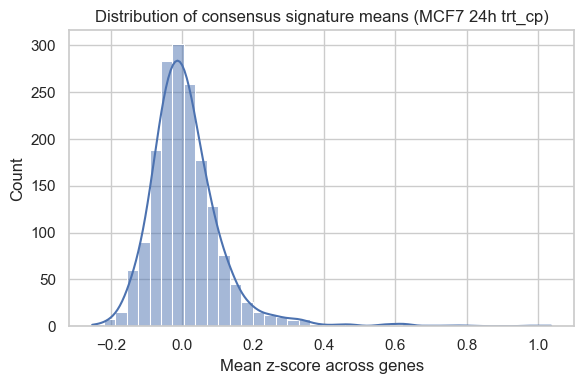

Number of genes (symbols): 12328
Number of perturbagens: 1732


In [20]:
# Distribution of mean expression per perturbagen (rough QC)
mean_per_pert = consensus_df_symbol.mean(axis=0)

plt.figure(figsize=(6,4))
sns.histplot(mean_per_pert, bins=40, kde=True)
plt.xlabel("Mean z-score across genes")
plt.title("Distribution of consensus signature means (MCF7 24h trt_cp)")
plt.tight_layout()
plt.show()

# Number of genes per symbol (after collapsing)
print("Number of genes (symbols):", consensus_df_symbol.shape[0])
print("Number of perturbagens:", consensus_df_symbol.shape[1])
